In [ ]:
# Retail Price Optimization at Bosch
# Final Project Presentation
# Author: Vivian Chioma Azeobike
# Date: April 30, 2025

In [ ]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier, GradientBoostingRegressor
from sklearn.metrics import accuracy_score, classification_report, mean_squared_error, r2_score
from sklearn.impute import SimpleImputer
import pickle
import datetime
import warnings
warnings.filterwarnings('ignore')

In [37]:
from google.colab import files

# Upload files
uploaded = files.upload()

# Load datasets
df = pd.read_csv("retail_price.csv")

Saving retail_price.csv to retail_price (1).csv


In [38]:
df.columns

Index(['product_id', 'product_category_name', 'month_year', 'qty',
       'total_price', 'freight_price', 'unit_price', 'product_name_lenght',
       'product_description_lenght', 'product_photos_qty', 'product_weight_g',
       'product_score', 'customers', 'weekday', 'weekend', 'holiday', 'month',
       'year', 's', 'volume', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2',
       'comp_3', 'ps3', 'fp3', 'lag_price'],
      dtype='object')

### **Variable Definition Table**

| **No.** | **Variable Name**              | **Description**                                                                 |
|--------:|--------------------------------|---------------------------------------------------------------------------------|
| 1       | `product_id`                   | Unique number for each product                                                  |
| 2       | `product_category_name`        | Product group                                                                   |
| 3       | `mont_year`                    | Date-time stamp                                                                 |
| 4       | `qty`                          | Quantity of product sold                                                        |
| 5       | `total_price`                  | Total price of the product (`qty * unit_price`)                                 |
| 6       | `freight_price`                | Rate based on mode of transportation from source to destination                |
| 7       | `unit_price`                   | Unit price of the product                                                       |
| 8       | `product_name_length`          | Length of the product name                                                      |
| 9       | `product_description_length`   | Length of the product description                                               |
| 10      | `product_photos_qty`           | Number of photos for the product                                                |
| 11      | `product_weight_g`             | Weight of the product in grams                                                  |
| 12      | `product_score`                | Average product rating                                                          |
| 13      | `customers`                    | Number of customers in the category                                             |
| 14      | `Weekday`                      | Number of weekdays in the month                                                 |
| 15      | `Weekend`                      | Number of weekends in the month                                                 |
| 16      | `holiday`                      | Number of holidays in the month                                                 |
| 17      | `month`                        | Month (in numeric format)                                                       |
| 18      | `year`                         | Year                                                                            |
| 19      | `s`                            | Seasonality (exact calculation method unknown)                                  |
| 20      | `volume`                       | Volume of the product                                                           |
| 21      | `comp_1`                       | Price of competitor 1                                                           |
| 22      | `ps1`                          | Product rating of competitor 1                                                  |
| 23      | `fp1`                          | Freight price of competitor 1                                                   |
| 24      | `comp_2`                       | Price of competitor 2                                                           |
| 25      | `ps2`                          | Product rating of competitor 2                                                  |
| 26      | `fp2`                          | Freight price of competitor 2                                                   |
| 27      | `comp_3`                       | Price of competitor 3                                                           |
| 28      | `ps3`                          | Product rating of competitor 3                                                  |
| 29      | `fp3`                          | Freight price of competitor 3                                                   |
| 30      | `lag_price`                    | Price of the product in the previous month                                      |


In [39]:
# Display basic information about the dataset
print("\nDataset Shape:", df.shape)
print("\nFirst 5 rows of the dataset:")
df.head()


Dataset Shape: (676, 30)

First 5 rows of the dataset:


,product_id,product_category_name,month_year,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
0,bed1,bed_bath_table,01-05-2017,1,45.95,15.100000,45.95,39,161,2,...,89.9,3.9,15.011897,215.000000,4.4,8.760000,45.95,4.0,15.100000,45.90
1,bed1,bed_bath_table,01-06-2017,3,137.85,12.933333,45.95,39,161,2,...,89.9,3.9,14.769216,209.000000,4.4,21.322000,45.95,4.0,12.933333,45.95
2,bed1,bed_bath_table,01-07-2017,6,275.70,14.840000,45.95,39,161,2,...,89.9,3.9,13.993833,205.000000,4.4,22.195932,45.95,4.0,14.840000,45.95
3,bed1,bed_bath_table,01-08-2017,4,183.80,14.287500,45.95,39,161,2,...,89.9,3.9,14.656757,199.509804,4.4,19.412885,45.95,4.0,14.287500,45.95
4,bed1,bed_bath_table,01-09-2017,2,91.90,15.100000,45.95,39,161,2,...,89.9,3.9,18.776522,163.398710,4.4,24.324687,45.95,4.0,15.100000,45.95


Exploring the dataset

In [40]:
# Display summary statistics
print("\nSummary statistics:")
df.describe()


Summary statistics:


,qty,total_price,freight_price,unit_price,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_score,customers,...,comp_1,ps1,fp1,comp_2,ps2,fp2,comp_3,ps3,fp3,lag_price
count,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,...,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000,676.000000
mean,14.495562,1422.708728,20.682270,106.496800,48.720414,767.399408,1.994083,1847.498521,4.085503,81.028107,...,79.452054,4.159467,18.597610,92.930079,4.123521,18.620644,84.182642,4.002071,17.965007,107.399684
std,15.443421,1700.123100,10.081817,76.182972,9.420715,655.205015,1.420473,2274.808483,0.232021,62.055560,...,47.933358,0.121652,9.406537,49.481269,0.207189,6.424174,47.745789,0.233292,5.533256,76.974657
min,1.000000,19.900000,0.000000,19.900000,29.000000,100.000000,1.000000,100.000000,3.300000,1.000000,...,19.900000,3.700000,0.095439,19.900000,3.300000,4.410000,19.900000,3.500000,7.670000,19.850000
25%,4.000000,333.700000,14.761912,53.900000,40.000000,339.000000,1.000000,348.000000,3.900000,34.000000,...,49.910000,4.100000,13.826429,53.900000,4.100000,14.485000,53.785714,3.900000,15.042727,55.668750
50%,10.000000,807.890000,17.518472,89.900000,51.000000,501.000000,1.500000,950.000000,4.100000,62.000000,...,69.900000,4.200000,16.618984,89.990000,4.200000,16.811765,59.900000,4.000000,16.517110,89.900000
75%,18.000000,1887.322500,22.713558,129.990000,57.000000,903.000000,2.000000,1850.000000,4.200000,116.000000,...,104.256549,4.200000,19.732500,117.888889,4.200000,21.665238,99.990000,4.100000,19.447778,129.990000
max,122.000000,12095.000000,79.760000,364.000000,60.000000,3006.000000,8.000000,9750.000000,4.500000,339.000000,...,349.900000,4.500000,57.230000,349.900000,4.400000,57.230000,255.610000,4.400000,57.230000,364.000000


**# Data Cleaning, Preparation and Preprocessing**

In [41]:
# Check for duplicate entries
print("\nChecking for duplicates:")
duplicates = df.duplicated().sum()
print(f"Number of duplicate rows: {duplicates}")
if duplicates > 0:
    df = df.drop_duplicates()
    print("Duplicates removed")


Checking for duplicates:
Number of duplicate rows: 0


In [42]:
print("\nChecking for Missing Values:")
print(df.isnull().sum())


Checking for Missing Values:
product_id                    0
product_category_name         0
month_year                    0
qty                           0
total_price                   0
freight_price                 0
unit_price                    0
product_name_lenght           0
product_description_lenght    0
product_photos_qty            0
product_weight_g              0
product_score                 0
customers                     0
weekday                       0
weekend                       0
holiday                       0
month                         0
year                          0
s                             0
volume                        0
comp_1                        0
ps1                           0
fp1                           0
comp_2                        0
ps2                           0
fp2                           0
comp_3                        0
ps3                           0
fp3                           0
lag_price                     0
dtype: int

In [43]:
# Convert month_year to datetime
df['month_year'] = pd.to_datetime(df['month_year'])

# Order the data by month_year
df = df.sort_values(by='month_year')

**# Exploratory Data Analysis**

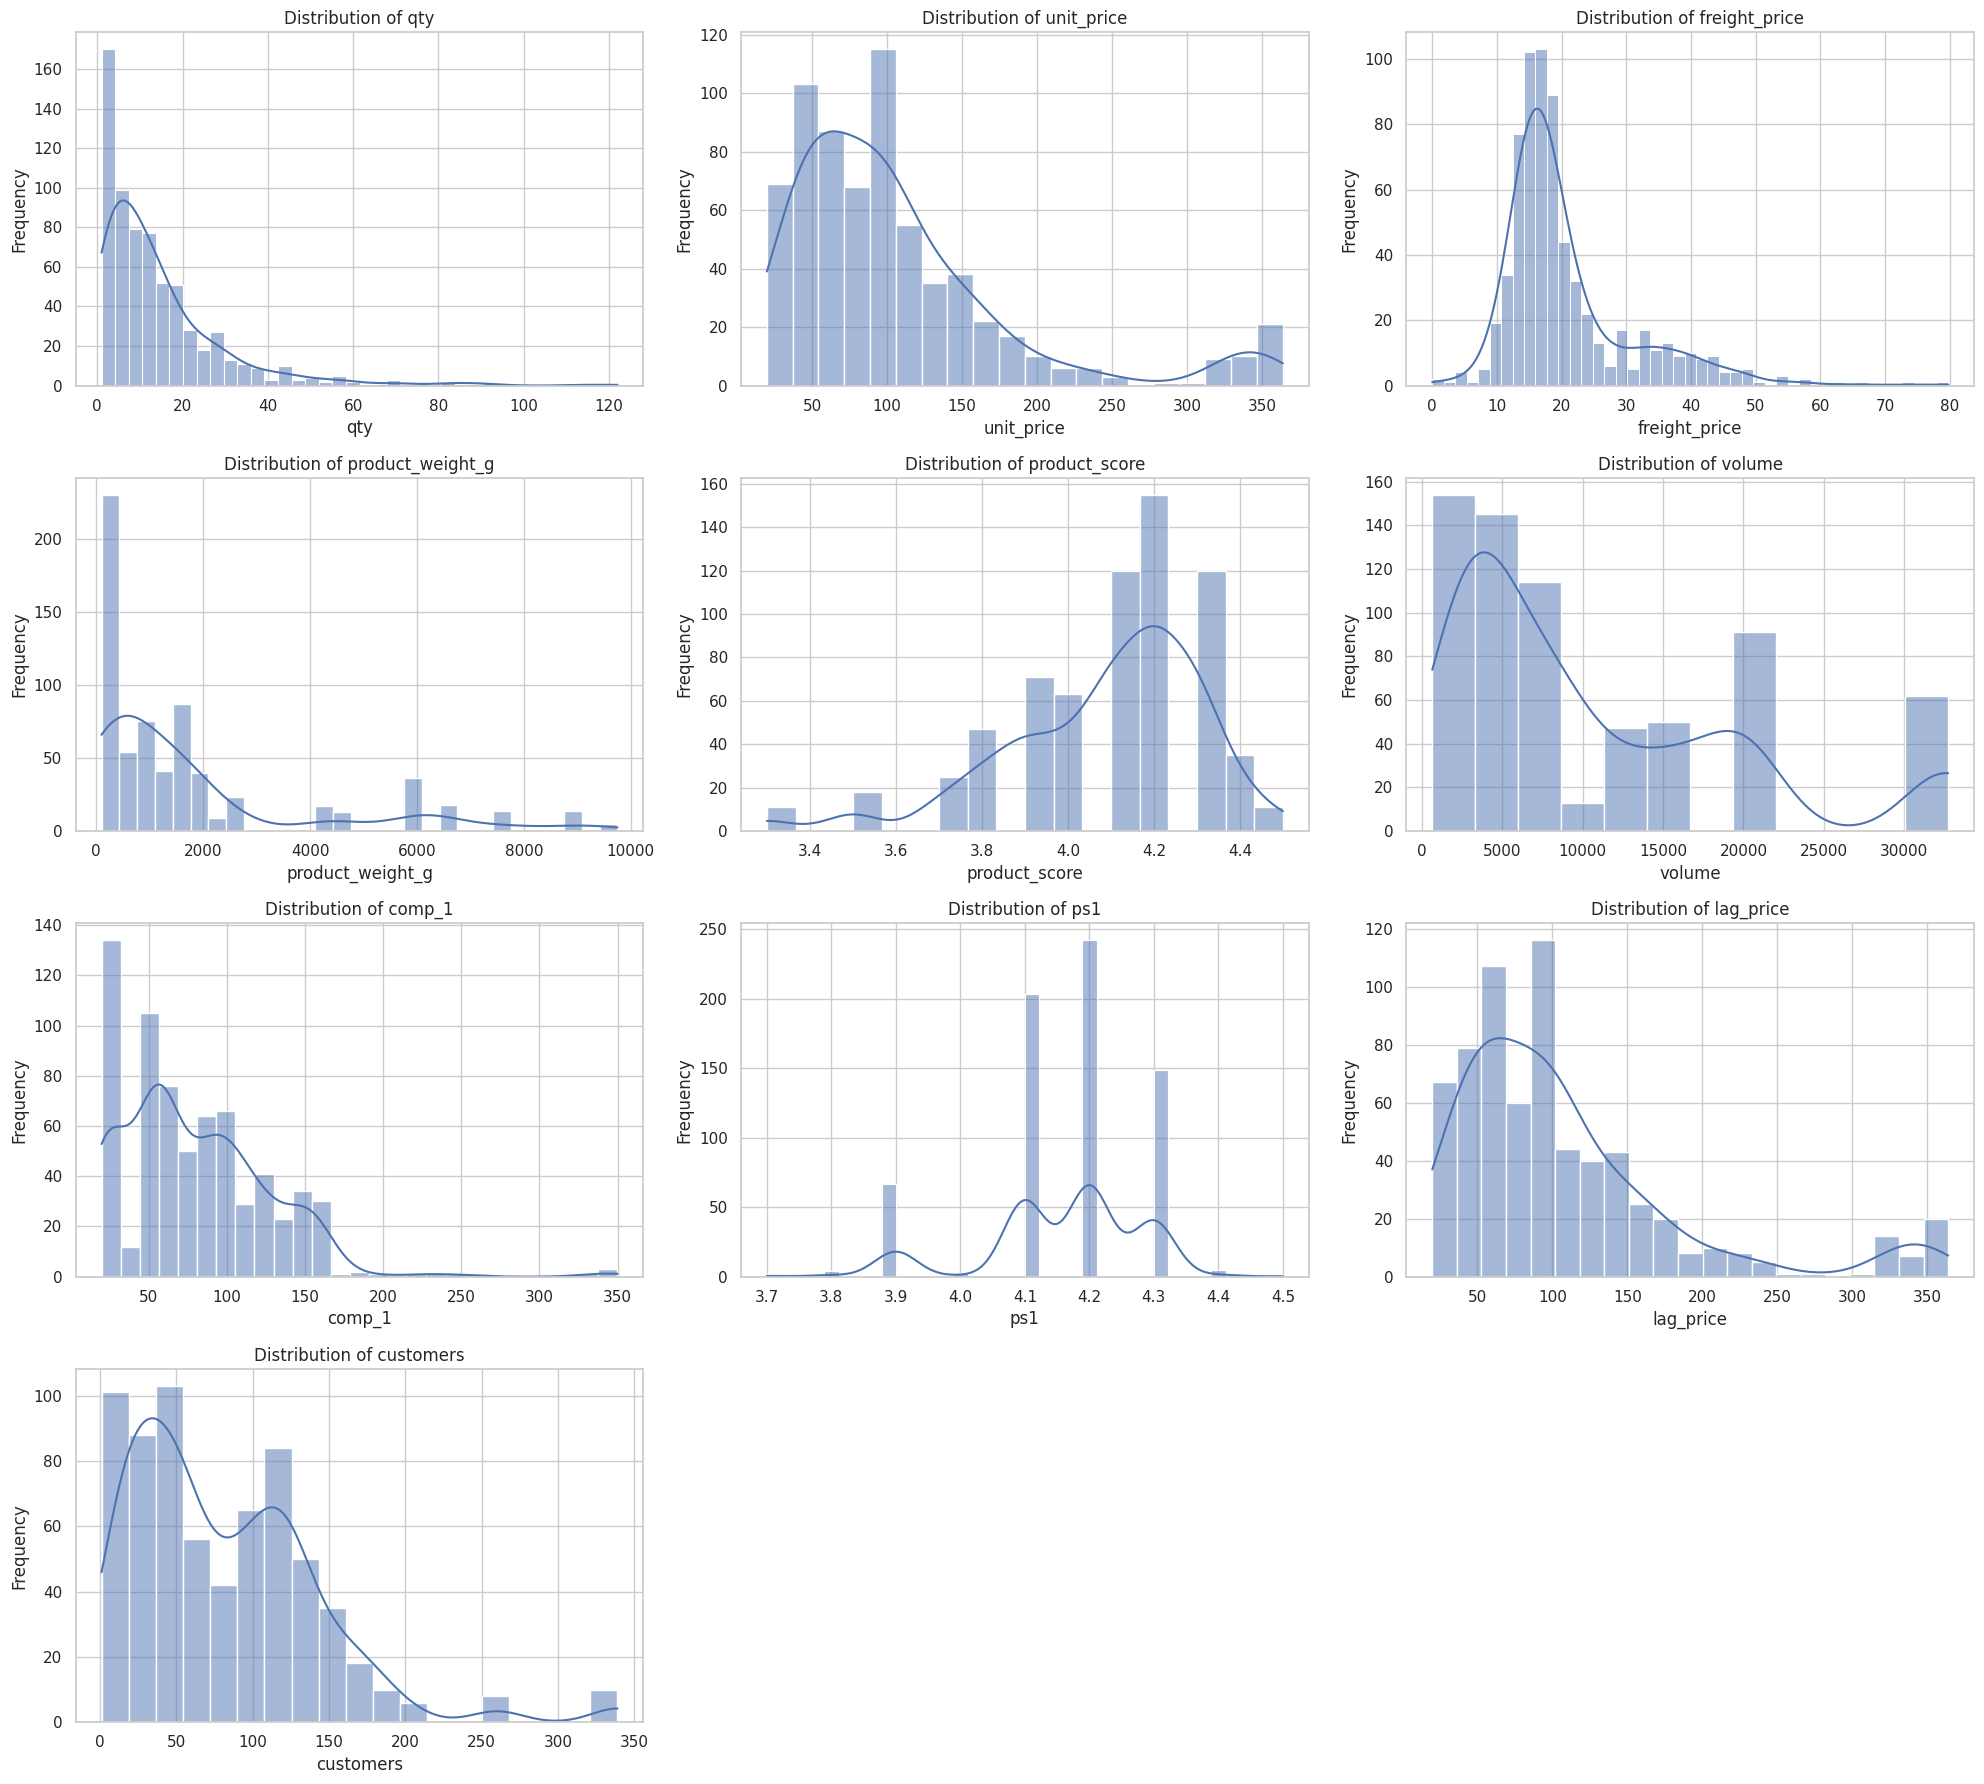

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

# 10 important variables
important_cols = [
    'qty',
    'unit_price',
    'freight_price',
    'product_weight_g',
    'product_score',
    'volume',
    'comp_1',
    'ps1',
    'lag_price',
    'customers'
]

# Set up subplots (4 rows x 3 columns to fit 10 plots)
fig, axes = plt.subplots(4, 3, figsize=(20, 18))
axes = axes.flatten()

# Plot histograms
for i, col in enumerate(important_cols):
    sns.histplot(df[col], ax=axes[i], kde=True)
    axes[i].set_title(f'Distribution of {col}')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

# Turn off any unused axes
for j in range(len(important_cols), len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


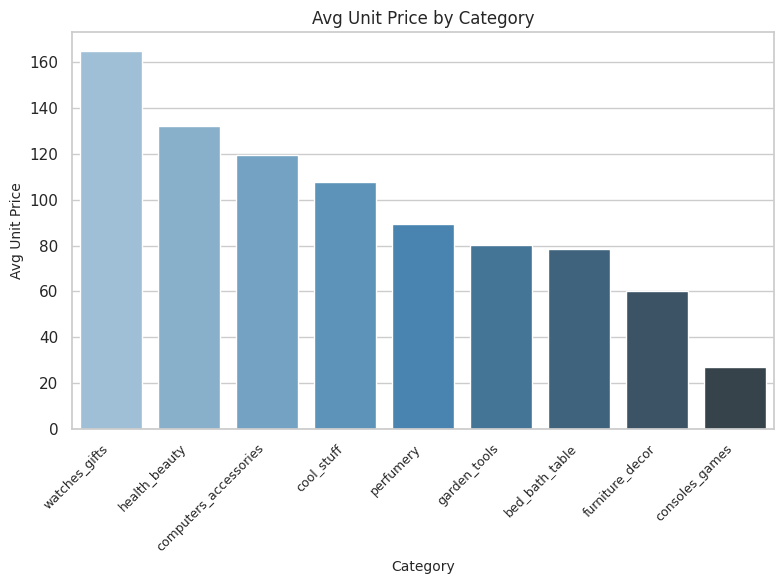

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt

# Compute average unit price by category
prod_cat = df.groupby("product_category_name")["unit_price"].mean().reset_index()

# Sort and select top categories (optional, you can skip this line if you want all)
prod_cat = prod_cat.sort_values(by="unit_price", ascending=False)

# Set smaller figure size
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")

# Plot
sns.barplot(data=prod_cat, x="product_category_name", y="unit_price", palette="Blues_d")

# Customize plot
plt.title("Avg Unit Price by Category", fontsize=12)
plt.xlabel("Category", fontsize=10)
plt.ylabel("Avg Unit Price", fontsize=10)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.tight_layout()

# Save & Show
plt.savefig("small_unit_price_by_category.png")
plt.show()


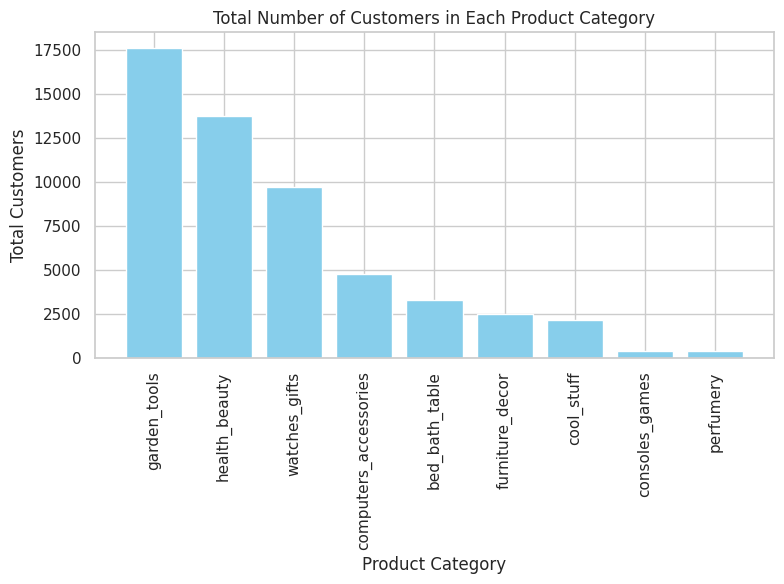

In [50]:
# Aggregate the total number of customers for each product category
category_customers = df.groupby('product_category_name')['customers'].sum().reset_index()

# Sort categories by total customers
category_customers = category_customers.sort_values(by='customers', ascending=False)

# Set smaller figure size
plt.figure(figsize=(8, 6))
sns.set(style="whitegrid")
plt.bar(category_customers['product_category_name'], category_customers['customers'], color='skyblue')
plt.xlabel('Product Category')
plt.ylabel('Total Customers')
plt.title('Total Number of Customers in Each Product Category')
plt.xticks(rotation=90)
plt.tight_layout()

# Display the plot
plt.show()

**# Correlation Plot**

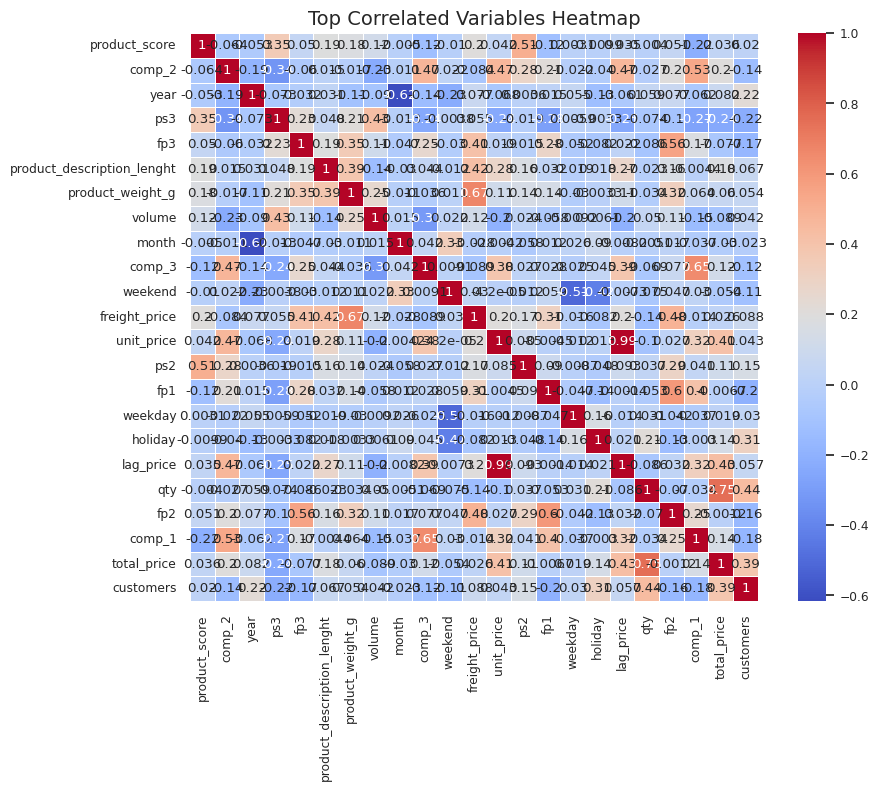

In [19]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Compute correlation matrix
corr_matrix = numeric_only.corr().abs()

# Remove self-correlations by setting the diagonal to 0
np.fill_diagonal(corr_matrix.values, 0)

# Find top N most correlated pairs
top_n = 20  # You can change this number
top_pairs = (
    corr_matrix.unstack()
    .sort_values(ascending=False)
    .drop_duplicates()
    .head(top_n)
)

# Extract unique variables from top correlated pairs
top_vars = list(set([i for i, j in top_pairs.index] + [j for i, j in top_pairs.index]))

# Filter correlation matrix for these variables
filtered_corr = numeric_only[top_vars].corr()

# Plot heatmap
plt.figure(figsize=(10, 8))
sns.set(font_scale=0.8)
sns.heatmap(filtered_corr, annot=True, cmap='coolwarm', linewidths=0.5, square=True)

plt.title('Top Correlated Variables Heatmap', fontsize=14)
plt.tight_layout()
plt.show()


**# Prepare data for machine learning (without splitting yet)**

In [20]:
#one-hot encoding
onehot_category = pd.get_dummies(df["product_category_name"], dtype=np.int8)

onehot_id = pd.get_dummies(df["product_id"], dtype=np.int8)
df = pd.concat([df, onehot_category, onehot_id], axis=1)
df.columns = df.columns.astype(str)

In [21]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler


# Scale numeric features
scaler = StandardScaler()
numeric_features = ['unit_price', 'freight_price', 'product_score', 'comp_1', 'ps1', 'fp1', 'comp_2', 'ps2', 'fp2', 'comp_3', 'ps3', 'fp3', 'lag_price']
df[numeric_features] = scaler.fit_transform(df[numeric_features])

df.dropna(inplace=True)  # Drop rows with NaN values created by lagging


In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# Ensure only numeric variables are selected
numeric_columns = df.select_dtypes(include=[np.number]).columns

# Define features (X) and target (y)
X = df[numeric_columns].drop(columns=['unit_price'])  # Drop 'unit_price' as it's the target variable
y = df['unit_price']

# Split the data into training and testing sets (80% train, 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Training set shape: {X_train.shape}")
print(f"Testing set shape: {X_test.shape}")

Training set shape: (540, 87)
Testing set shape: (136, 87)


The following models were fitted

**# 1. Linear Regression**

**# 2. Decision Tree Regressor**

**# 3. Random Forest Regressor**

**# 4. Gradient Boosting Regressor**

**# 5. Support Vector Regressor (SVR)**

**# Model Development**

                      Model       MSE      RMSE       MAE        R²
2             Random Forest  0.009170  0.095759  0.043381  0.989807
3         Gradient Boosting  0.012025  0.109657  0.054082  0.986633
0         Linear Regression  0.017562  0.132521  0.068663  0.980478
1             Decision Tree  0.020426  0.142921  0.055339  0.977294
4  Support Vector Regressor  0.049633  0.222785  0.127827  0.944827


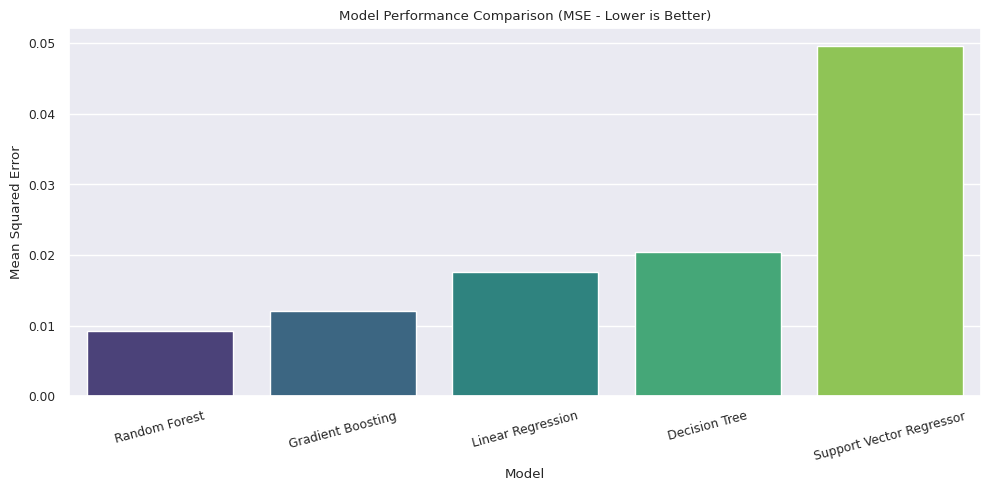

In [29]:
# Define models
models = {
    'Linear Regression': LinearRegression(),
    'Decision Tree': DecisionTreeRegressor(),
    'Random Forest': RandomForestRegressor(n_estimators=100, random_state=42),
    'Gradient Boosting': GradientBoostingRegressor(),
    'Support Vector Regressor': Pipeline([
        ('scaler', StandardScaler()),
        ('svr', SVR())
    ])
}

# Evaluate models and store metrics
metrics = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    mae = mean_absolute_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    metrics.append({
        'Model': name,
        'MSE': mse,
        'RMSE': rmse,
        'MAE': mae,
        'R²': r2
    })

# Convert to DataFrame for easy plotting
metrics_df = pd.DataFrame(metrics).sort_values(by='MSE')

# Print metrics table
print(metrics_df)

# Plot only MSE
plt.figure(figsize=(10, 5))
sns.barplot(x='Model', y='MSE', data=metrics_df, palette="viridis")
plt.ylabel('Mean Squared Error')
plt.title('Model Performance Comparison (MSE - Lower is Better)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### **Model Performance Interpretation**

From the results, we can observe the following metrics for each model:

| Model                   | MSE      | RMSE    | MAE     | R²      |
|-------------------------|----------|---------|---------|---------|
| Random Forest           | 0.009170 | 0.095759| 0.043381| 0.989807|
| Gradient Boosting       | 0.012025 | 0.109657| 0.054082| 0.986633|
| Linear Regression       | 0.017562 | 0.132521| 0.068663| 0.980478|
| Decision Tree           | 0.020426 | 0.142921| 0.055339| 0.977294|
| Support Vector Regressor| 0.049633 | 0.222785| 0.127827| 0.944827|

**# Best Model: Random Forest**
- **MSE (Mean Squared Error)**: The Random Forest model has the lowest MSE at 0.009170, indicating that it has the smallest average squared difference between the predicted and actual values. This suggests the model is performing well in predicting the target variable.
  
- **RMSE (Root Mean Squared Error)**: The RMSE for Random Forest is 0.095759, which is the lowest among all models, confirming its better prediction accuracy compared to the others.
  
- **MAE (Mean Absolute Error)**: The MAE of 0.043381 for Random Forest is also the smallest, which means that, on average, the model's predictions are off by approximately 0.043 units of the target value, making it the most accurate in terms of absolute errors.

- **R² (R-squared)**: The R² score of 0.989807 for Random Forest is the highest, which means that the model explains about 98.98% of the variance in the target variable. This is an excellent result, as it indicates that the Random Forest model does an outstanding job at capturing the relationships in the data.

#### **Conclusion:**
The **Random Forest** model is the best performer in this evaluation. It consistently achieves the lowest errors (MSE, RMSE, and MAE) and the highest R² score, making it the most accurate and reliable model for predicting the unit price.


In [32]:
import joblib

# Assuming you have already trained your model as `model`
# Save the model to a .pkl file using joblib
joblib.dump(model, 'Prediction_model.pkl')

print("Model saved as 'Prediction_model.pkl'")

Model saved as 'Prediction_model.pkl'


In [33]:
import joblib
from google.colab import files

# Download the file
files.download('Prediction_model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [34]:
model_columns = model.feature_names_in_  # This is available after fitting a model with pandas DataFrame
print(model_columns)

['qty' 'total_price' 'freight_price' 'product_name_lenght'
 'product_description_lenght' 'product_photos_qty' 'product_weight_g'
 'product_score' 'customers' 'weekday' 'weekend' 'holiday' 'month' 'year'
 's' 'volume' 'comp_1' 'ps1' 'fp1' 'comp_2' 'ps2' 'fp2' 'comp_3' 'ps3'
 'fp3' 'lag_price' 'bed_bath_table' 'computers_accessories'
 'consoles_games' 'cool_stuff' 'furniture_decor' 'garden_tools'
 'health_beauty' 'perfumery' 'watches_gifts' 'bed1' 'bed2' 'bed3' 'bed4'
 'bed5' 'computers1' 'computers2' 'computers3' 'computers4' 'computers5'
 'computers6' 'consoles1' 'consoles2' 'cool1' 'cool2' 'cool3' 'cool4'
 'cool5' 'furniture1' 'furniture2' 'furniture3' 'furniture4' 'garden1'
 'garden10' 'garden2' 'garden3' 'garden4' 'garden5' 'garden6' 'garden7'
 'garden8' 'garden9' 'health1' 'health10' 'health2' 'health3' 'health4'
 'health5' 'health6' 'health7' 'health8' 'health9' 'perfumery1'
 'perfumery2' 'watches1' 'watches2' 'watches3' 'watches4' 'watches5'
 'watches6' 'watches7' 'watches8']
